<a href="https://colab.research.google.com/github/tedrosredie/PyhonProjects/blob/deep-learning/simple_customer_behavior_prediction_with_neutral_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Behavior Prediction using Neural Networks

## Overview
This Python code demonstrates how to build and train a neural network model to predict customer purchasing behavior. The implementation uses deep learning techniques to analyze customer characteristics and historical interactions to forecast whether a customer is likely to make a purchase.

## Problem Statement
Customer behavior prediction is a crucial task in marketing and e-commerce that helps businesses:
- Identify potential buyers
- Optimize marketing campaigns
- Personalize customer experiences
- Improve conversion rates
- Enhance customer retention strategies

## Solution Approach
This implementation uses a multi-layer neural network to learn complex patterns from customer data. The model processes various customer attributes and behavioral metrics to predict purchase decisions with high accuracy.

## Key Features
- **Data Preparation**: Synthetic dataset generation with realistic customer attributes
- **Neural Network Architecture**: Deep learning model with multiple hidden layers and dropout regularization
- **Model Training**: Optimized training with early stopping and adaptive learning rates
- **Comprehensive Evaluation**: Multiple metrics and visualizations for performance assessment
- **Production Ready**: Easy adaptation for real-world customer data

## Technical Stack
- TensorFlow/Keras for neural network implementation
- Scikit-learn for data preprocessing and evaluation
- Pandas and NumPy for data manipulation
- Matplotlib and Seaborn for visualization

This code provides a complete framework for customer behavior prediction that can be easily customized and extended for specific business needs and real-world datasets.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Create a synthetic dataset (replace this with your own data)
def create_synthetic_data(n_samples=10000):
    np.random.seed(42)
    age = np.random.randint(18, 70, n_samples)
    income = np.random.normal(50000, 20000, n_samples)
    browsing_duration = np.random.exponential(30, n_samples)
    pages_visited = np.random.poisson(15, n_samples)
    previous_purchases = np.random.poisson(3, n_samples)

    # Create synthetic target variable (purchase decision)
    purchase_probability = (
        0.1 * (age - 40) / 30 +
        0.3 * (income - 50000) / 20000 +
        0.2 * (browsing_duration - 30) / 10 +
        0.25 * (pages_visited - 15) / 5 +
        0.15 * previous_purchases
    )
    purchased = purchase_probability + np.random.normal(0, 0.2, n_samples) > 0.5

    df = pd.DataFrame({
        'age': age,
        'income': income,
        'browsing_duration': browsing_duration,
        'pages_visited': pages_visited,
        'previous_purchases': previous_purchases,
        'purchased': purchased.astype(int)
    })
    return df

In [5]:
# Generate synthetic data
df = create_synthetic_data(10000)
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (10000, 6)

First 5 rows:
   age        income  browsing_duration  pages_visited  previous_purchases  \
0   56  32952.264679          31.233471             17                   3   
1   69  59507.312214          61.118370             21                   4   
2   46  62649.084333          44.869496             12                   6   
3   32  40516.436498          29.835179             16                   1   
4   60  34564.560852         120.956998             13                   4   

   purchased  
0          0  
1          1  
2          1  
3          0  
4          1  


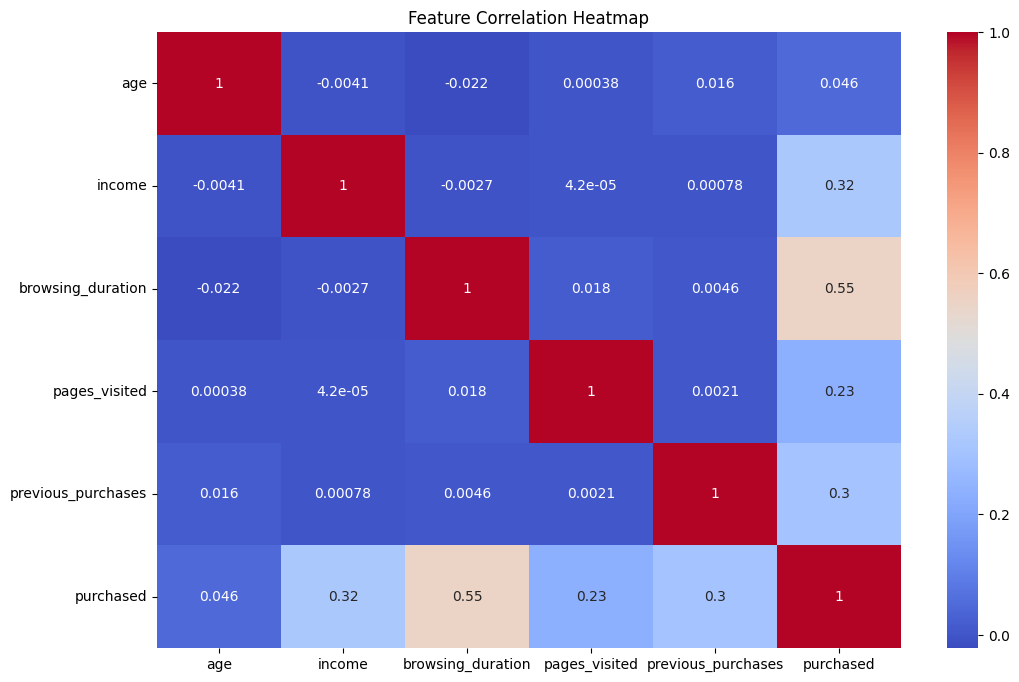

In [6]:
# Exploratory Data Analysis
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
# Prepare data for training
X = df.drop('purchased', axis=1)
y = df['purchased']


In [8]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Build neural network model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Display model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
    ]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8004 - loss: 0.4502 - val_accuracy: 0.9038 - val_loss: 0.2100 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8982 - loss: 0.2391 - val_accuracy: 0.9031 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9006 - loss: 0.2320 - val_accuracy: 0.9038 - val_loss: 0.2062 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.2234 - val_accuracy: 0.9044 - val_loss: 0.2042 - learning_rate: 0.0010
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9066 - loss: 0.2189 - val_accuracy: 0.9025 - val_loss: 0.2020 - learning_rate: 0.0010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9006 - loss: 0.2237 - val_accuracy: 0.9031 - val_loss: 0.2023 - learning_rate: 0.0010
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.2203 - 

In [14]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9042 - loss: 0.2096

Test Accuracy: 0.9085
Test Loss: 0.1978


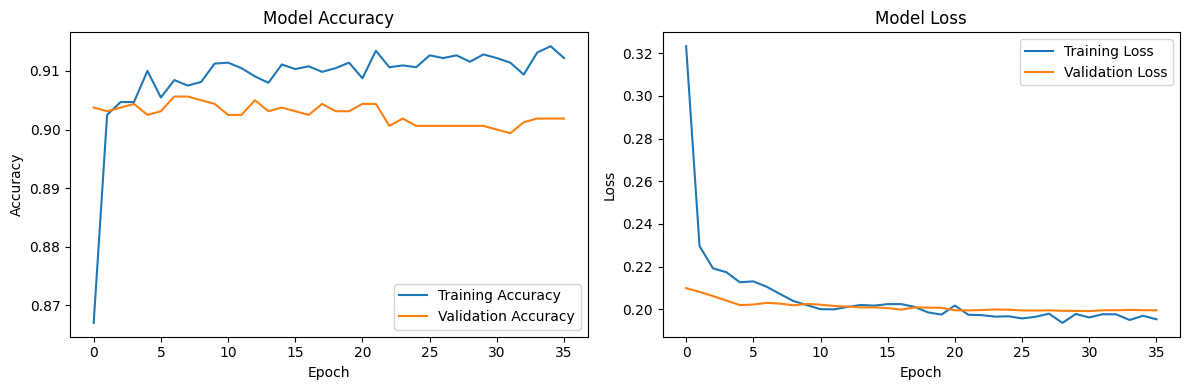

In [15]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Make predictions
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1163
           1       0.90      0.88      0.89       837

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.91      2000
weighted avg       0.91      0.91      0.91      2000



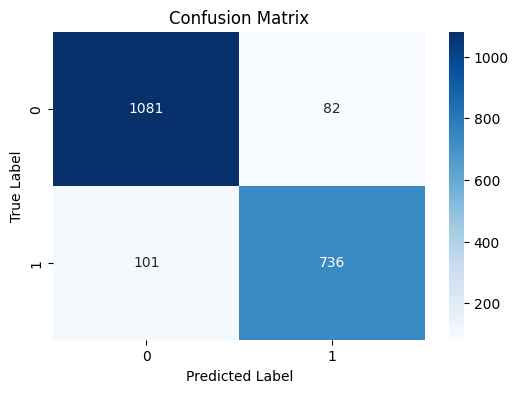

In [18]:
# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [19]:
# Predict new customer behavior (example)
new_customer = np.array([[35, 60000, 45, 20, 2]])  # Replace with actual values
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)
print(f"\nNew customer purchase probability: {prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

New customer purchase probability: 0.9903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
